In [4]:
# !git clone https://huggingface.co/datasets/dvrkdvys/SZA_Singing

# EDA test dataset

In [4]:
!pip install soundfile ffmpeg-python tqdm

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)


--- Bắt đầu phân tích EDA ---
Bắt đầu quét thư mục: /Users/duongthanhduy/DSP501.22_Assessment/SZA_Singing...
Tìm thấy tổng cộng 135 file audio.


Đang phân tích audio: 100%|██████████| 135/135 [00:00<00:00, 2888.31it/s]


--- BÁO CÁO TÓM TẮT DATASET ---
Tổng số file: 135
Tổng thời lượng: 2817.36 giây (~ 46.96 phút)
Thời lượng trung bình: 20.87 giây

Phân phối Tần số Lấy mẫu (Sample Rate):
sample_rate_hz
44100    135

Phân phối Thời lượng (Giây):
count    135.000000
mean      20.869349
std       25.825208
min        1.590567
25%        5.648254
50%       10.623129
75%       24.816327
max      138.634739



Đã lưu biểu đồ phân phối thời lượng tại: /Users/duongthanhduy/DSP501.22_Assessment/output_analysis/eda_duration_histogram.png


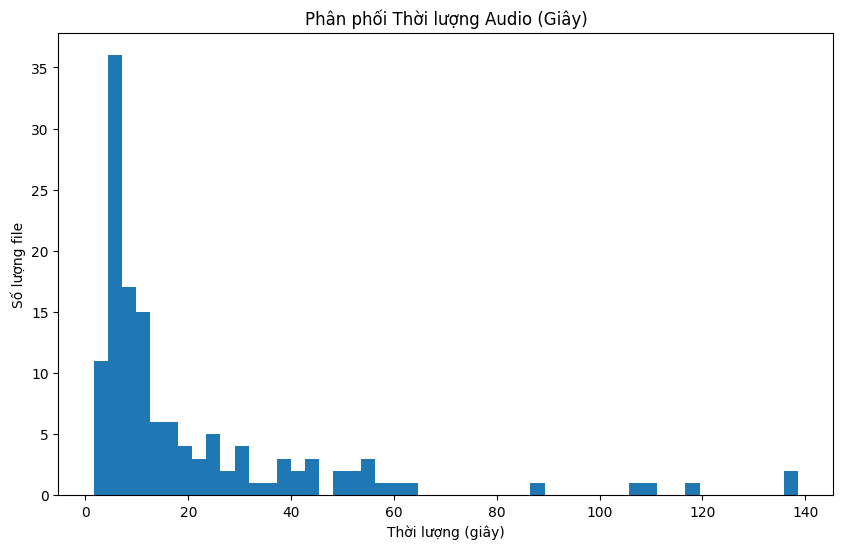

--- Phân tích hoàn tất! ---


In [8]:
import os
import librosa
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
from pathlib import Path

# --- CÁC HÀM PHÂN TÍCH ---

def analyze_dataset(dataset_path):
    """
    Phân tích một thư mục dataset audio.
    Trả về một DataFrame với thông tin file (tần số lấy mẫu, thời lượng).
    """
    dataset_path_obj = Path(dataset_path)
    print(f"Bắt đầu quét thư mục: {dataset_path_obj.resolve()}...")
    audio_files = []

    # --- SỬA LỖI LOGIC QUÉT FILE ---
    # Quét trực tiếp các file audio trong thư mục gốc
    for file in dataset_path_obj.iterdir():
        if file.suffix.lower() in ('.wav', '.flac', '.mp3', '.m4a'):
            audio_files.append(str(file.resolve()))
    # -------------------------------

    print(f"Tìm thấy tổng cộng {len(audio_files)} file audio.")

    data = []

    # Tắt cảnh báo của Librosa khi đọc file
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for file_path in tqdm(audio_files, desc="Đang phân tích audio"):
            try:
                # Dùng sr=None để lấy tần số gốc
                sr = librosa.get_samplerate(file_path)
                # Lấy thời lượng
                duration = librosa.get_duration(path=file_path)
                data.append({
                    'file_path': file_path,
                    'duration_seconds': duration,
                    'sample_rate_hz': sr
                })
            except Exception as e:
                # In ra lỗi chi tiết
                print(f"\n--- LỖI KHI XỬ LÝ FILE ---")
                print(f"File: {file_path}")
                print(f"Lỗi: {e}")
                print(f"----------------------------\n")

    return pd.DataFrame(data)

def generate_report(df, output_path):
    """
    Tạo báo cáo tóm tắt và lưu biểu đồ.
    """
    if df.empty:
        print("Không có dữ liệu audio để báo cáo.")
        return

    print("\n--- BÁO CÁO TÓM TẮT DATASET ---")

    total_files = len(df)
    total_duration_sec = df['duration_seconds'].sum()
    total_duration_min = total_duration_sec / 60
    mean_duration_sec = df['duration_seconds'].mean()

    print(f"Tổng số file: {total_files}")
    print(f"Tổng thời lượng: {total_duration_sec:.2f} giây (~ {total_duration_min:.2f} phút)")
    print(f"Thời lượng trung bình: {mean_duration_sec:.2f} giây")

    print("\nPhân phối Tần số Lấy mẫu (Sample Rate):")
    # Tần số lấy mẫu thường rất quan trọng trong DSP
    print(df['sample_rate_hz'].value_counts().to_string())

    print("\nPhân phối Thời lượng (Giây):")
    print(df['duration_seconds'].describe().to_string())

    # Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    df['duration_seconds'].plot(kind='hist', bins=50, title='Phân phối Thời lượng Audio (Giây)')
    plt.xlabel('Thời lượng (giây)')
    plt.ylabel('Số lượng file')

    histogram_path = os.path.join(output_path, 'eda_duration_histogram.png')
    os.makedirs(output_path, exist_ok=True)
    plt.savefig(histogram_path)
    print(f"\nĐã lưu biểu đồ phân phối thời lượng tại: {histogram_path}")
    plt.show()

# --- PHẦN ĐỂ CHẠY TRONG NOTEBOOK ---

# 1. CẤU HÌNH ĐƯỜNG DẪN:
#    (Giả sử bạn chạy Notebook/code từ thư mục cha của SZA_Singing)
base_project_path = Path.cwd()

# ĐIỀU CHỈNH ĐƯỜNG DẪN NÀY NẾU CẦN
dataset_path = base_project_path / "SZA_Singing"
output_path = base_project_path / "output_analysis"

# --- CHẠY PHÂN TÍCH ---
print("--- Bắt đầu phân tích EDA ---")
df = analyze_dataset(str(dataset_path))
generate_report(df, str(output_path))
print("--- Phân tích hoàn tất! ---")